In [1]:
%load_ext dotenv
%dotenv /home/aurora/.env
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import datetime as dt
from google.cloud import bigquery
import re
import pymongo
import os
import seaborn as sns
from flatten_json import flatten
import matplotlib.pyplot as plt
client = bigquery.Client.from_service_account_json('/home/analytics/.secure_files/hitwicketsuperstars-f3e8c620a88c.json')

In [3]:
start = str(dt.date(2019,6,22))
end = str(dt.date(2019,6,25))
print(start,end)

2019-06-22 2019-06-25


In [4]:
app_version = '2.0.2'

In [5]:
query = (f"""
             SELECT 
             user_id as device_id,
             event_timestamp
             FROM `hitwicketsuperstars.analytics_190927423.events_*`,
             UNNEST(event_params) AS params    
             WHERE _TABLE_SUFFIX BETWEEN "{start.replace('-','')}"
             AND "{end.replace('-','')}"
             AND app_info.version = '{app_version}'
            AND device.operating_system = 'ANDROID'
             AND params.key = 'action'
            AND event_name IN ('natasha')
           AND params.value.string_value = 'hand_pointer_achievements_clicked'""")
         
ftue_complete = client.query(query).to_dataframe() 

In [6]:
ftue_complete.sort_values('event_timestamp',ascending=False,inplace=True)
ftue_complete.drop_duplicates('device_id',inplace=True)
print(len(ftue_complete))
ftue_complete.head()

662


,device_id,event_timestamp
618,6b056d68bd15b40b34b4c8adacfb7b7b,1561485137278007
620,6e8366b7cc01dbcf7b750ad91780fd16,1561484489783008
617,34c873853ad3d70f45a94206c98adc6b,1561483865207008
599,cd4ff9c6ae167ad96b940bc38781ad67,1561483529940008
581,c592d90d27a59033fe90f43bcec8cd0c,1561483466834008


In [7]:
query = (
    f"""SELECT
  user_id as device_id,
  event_name,
  event_timestamp,
  params.value.string_value
  FROM `hitwicketsuperstars.analytics_190927423.events_*`,
  UNNEST(event_params) AS params
  WHERE _TABLE_SUFFIX BETWEEN "{start.replace('-','')}"
  AND "{end.replace('-','')}"
  AND app_info.version = '{app_version}'
  AND params.key IN ('action')"""
)
trackers = client.query(query).to_dataframe()
len(trackers)

335845

In [8]:
print(len(trackers))
trackers.head()

335845


,device_id,event_name,event_timestamp,string_value
0,45f5fcc522f21a6e6d7aaf3937ff91ef,signup,1561295875898002,new_user_hand_pointer_click
1,45f5fcc522f21a6e6d7aaf3937ff91ef,ftue,1561295903569000,natasha_welcome1_seen
2,45f5fcc522f21a6e6d7aaf3937ff91ef,ftue,1561295904433001,natasha_welcome1_clicked
3,45f5fcc522f21a6e6d7aaf3937ff91ef,ftue,1561295904433002,natasha_welcome2_seen
4,45f5fcc522f21a6e6d7aaf3937ff91ef,ftue,1561295906249003,natasha_welcome3_seen


In [9]:
merged = pd.merge(ftue_complete,trackers,on='device_id',how='inner',suffixes = ['_created',''])

In [10]:
merged = merged[(merged['event_timestamp']>merged['event_timestamp_created'])]

In [11]:
not_needed = ['achievements_tab_clicked','right_arrow_scroll','left_arrow_scroll','natasha_stadium_ready_inaugrate_seen']
merged = merged[~merged['string_value'].isin(not_needed)]

In [12]:
print(len(merged))
merged.head()

75803


,device_id,event_timestamp_created,event_name,event_timestamp,string_value
95,6b056d68bd15b40b34b4c8adacfb7b7b,1561485137278007,daily_task,1561485157114009,task_claim_reward
96,6b056d68bd15b40b34b4c8adacfb7b7b,1561485137278007,bottom_menu,1561485187166010,squad
97,6b056d68bd15b40b34b4c8adacfb7b7b,1561485137278007,hud,1561485236084013,back_button
98,6b056d68bd15b40b34b4c8adacfb7b7b,1561485137278007,hud,1561485337395014,back_button
99,6b056d68bd15b40b34b4c8adacfb7b7b,1561485137278007,hud,1561485409651015,back_button


In [13]:
merged.sort_values(['device_id','event_timestamp'],inplace=True)
len(merged)

75803

In [14]:
top_activity = merged.groupby('device_id').head(1)
len(top_activity)

642

In [15]:
len(top_activity)/len(ftue_complete)*100

96.97885196374622

In [16]:
grouping = top_activity.groupby('string_value').agg({'device_id':'count'}).sort_values('device_id',ascending=False)

In [17]:
grouping['percentage'] = grouping['device_id']/grouping['device_id'].sum()

In [214]:
grouping.head()

,device_id,percentage
string_value,,
go,467,0.420721
task_claim_reward,337,0.303604
store,108,0.097297
world_tour_clicked,66,0.059459
daily_quests,40,0.036036


In [215]:
top_place = grouping.head(10)

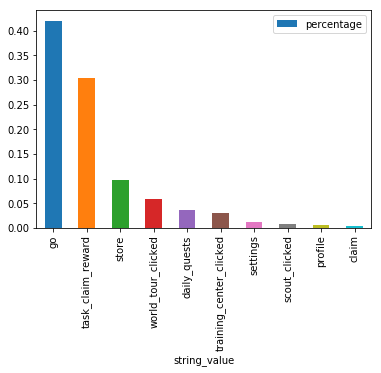

In [216]:
graph = top_place.plot.bar( y = 'percentage')

In [217]:
fig = graph.get_figure()
fig.savefig('image.png')

In [218]:
query = (
    f"""SELECT
  user_id as device_id,
  event_name,
  event_timestamp,
  params.value.int_value
  FROM `hitwicketsuperstars.analytics_190927423.events_*`,
  UNNEST(event_params) AS params
  WHERE _TABLE_SUFFIX BETWEEN "{start.replace('-','')}"
  AND "{end.replace('-','')}"
    AND event_name = 'achievement'
  AND app_info.version = '{app_version}'
  AND params.key IN ('id')"""
)
go_id = client.query(query).to_dataframe()
len(go_id)

2819

In [219]:
go_id.head()

,device_id,event_name,event_timestamp,int_value
0,7f805b1bdc84b9241973f0d55ce5fe25,achievement,1560882597922008,13
1,8c6d11d72aa52f930a7d74283bd41a4d,achievement,1560868302860007,13
2,d3447a8998370d0f4fcc95ed8f9c600e,achievement,1560880518279010,1
3,d3447a8998370d0f4fcc95ed8f9c600e,achievement,1560880532959011,13
4,6f89b31b08893850f3222bb5a9e27837,achievement,1560879885600005,4


In [220]:
go_activity = top_activity[top_activity['string_value']=='go']

In [221]:
go_id.head()

,device_id,event_name,event_timestamp,int_value
0,7f805b1bdc84b9241973f0d55ce5fe25,achievement,1560882597922008,13
1,8c6d11d72aa52f930a7d74283bd41a4d,achievement,1560868302860007,13
2,d3447a8998370d0f4fcc95ed8f9c600e,achievement,1560880518279010,1
3,d3447a8998370d0f4fcc95ed8f9c600e,achievement,1560880532959011,13
4,6f89b31b08893850f3222bb5a9e27837,achievement,1560879885600005,4


In [222]:
go_merged = pd.merge(go_activity[['device_id','event_timestamp','string_value']],
                     go_id,on=['device_id','event_timestamp'],how = 'left')
len(go_merged)

470

In [223]:
go_merged.head()

,device_id,event_timestamp,string_value,event_name,int_value
0,0069239b27b56243f564f68a0936c2a8,1560946702068007,go,achievement,13.0
1,0076c36557f0bcb4765d3dcb8bbe1775,1561025555563008,go,achievement,13.0
2,00bcd9ca2b73911368132fb53a8563e6,1560566550876007,go,achievement,13.0
3,00c0d9f791265c3ac894175aa14e9c0f,1561172927283008,go,achievement,13.0
4,01d9271e9b632a6ef01444d91d01c26b,1560585484045008,go,achievement,13.0


In [224]:
go_distribution = go_merged.groupby('int_value').agg({'device_id':'count'})

In [226]:
go_distribution.sort_values('device_id',inplace=True,ascending=False)
go_distribution

,device_id
int_value,
13.0,407
1.0,32
4.0,5
16.0,5
19.0,5
7.0,4
10.0,3


In [227]:
grouping

,device_id,percentage
string_value,,
go,467,0.420721
task_claim_reward,337,0.303604
store,108,0.097297
world_tour_clicked,66,0.059459
daily_quests,40,0.036036
training_center_clicked,34,0.030631
settings,14,0.012613
scout_clicked,9,0.008108
profile,7,0.006306
